In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join("COVID-19 Dataset", "country_wise_latest.csv"))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

COVID-19 Dataset/country_wise_latest.csv
COVID-19 Dataset/country_wise_latest.csv
COVID-19 Dataset/country_wise_latest.csv
COVID-19 Dataset/country_wise_latest.csv
COVID-19 Dataset/country_wise_latest.csv
COVID-19 Dataset/country_wise_latest.csv


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

import os
if not os.path.exists('/kaggle/working/output'):
    os.makedirs('/kaggle/working/output')

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv('/kaggle/input/datasets/imdevskp/corona-virus-report/country_wise_latest.csv') 

# Display basic information
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nDataset Info:")
df.info()

print(f"\nBasic Statistics:")
print(df.describe())

print(f"\nMissing Values:")
print(df.isnull().sum())

DATASET OVERVIEW
Dataset Shape: (187, 15)

First 5 rows:
  Country/Region  Confirmed  Deaths  Recovered  Active  New cases  New deaths  \
0    Afghanistan      36263    1269      25198    9796        106          10   
1        Albania       4880     144       2745    1991        117           6   
2        Algeria      27973    1163      18837    7973        616           8   
3        Andorra        907      52        803      52         10           0   
4         Angola        950      41        242     667         18           1   

   New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0             18                3.50                  69.49   
1             63                2.95                  56.25   
2            749                4.16                  67.34   
3              0                5.73                  88.53   
4              0                4.32                  25.47   

   Deaths / 100 Recovered  Confirmed last week  1 week change  \
0           

In [5]:

df_clean = df.dropna(subset=['Confirmed', 'Deaths', 'Recovered'])

# Convert percentage columns to numeric if they're strings
percentage_columns = ['Deaths / 100 Cases', 'Recovered / 100 Cases', 'Deaths / 100 Recovered']
for col in percentage_columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].str.rstrip('%').astype('float') / 100.0

# Calculate additional metrics
df_clean['Mortality_Rate'] = (df_clean['Deaths'] / df_clean['Confirmed']) * 100
df_clean['Recovery_Rate'] = (df_clean['Recovered'] / df_clean['Confirmed']) * 100
df_clean['Active_Rate'] = (df_clean['Active'] / df_clean['Confirmed']) * 100
df_clean['Case_Fatality_Ratio'] = (df_clean['Deaths'] / df_clean['Recovered']) * 100

# Sort by confirmed cases
df_sorted = df_clean.sort_values('Confirmed', ascending=False).reset_index(drop=True)

print("Data cleaning completed!")
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"\nTop 10 countries by confirmed cases:")
print(df_sorted[['Country/Region', 'Confirmed', 'Deaths', 'Recovered']].head(10))

Data cleaning completed!
Cleaned dataset shape: (187, 19)

Top 10 countries by confirmed cases:
   Country/Region  Confirmed  Deaths  Recovered
0              US    4290259  148011    1325804
1          Brazil    2442375   87618    1846641
2           India    1480073   33408     951166
3          Russia     816680   13334     602249
4    South Africa     452529    7067     274925
5          Mexico     395489   44022     303810
6            Peru     389717   18418     272547
7           Chile     347923    9187     319954
8  United Kingdom     301708   45844       1437
9            Iran     293606   15912     255144


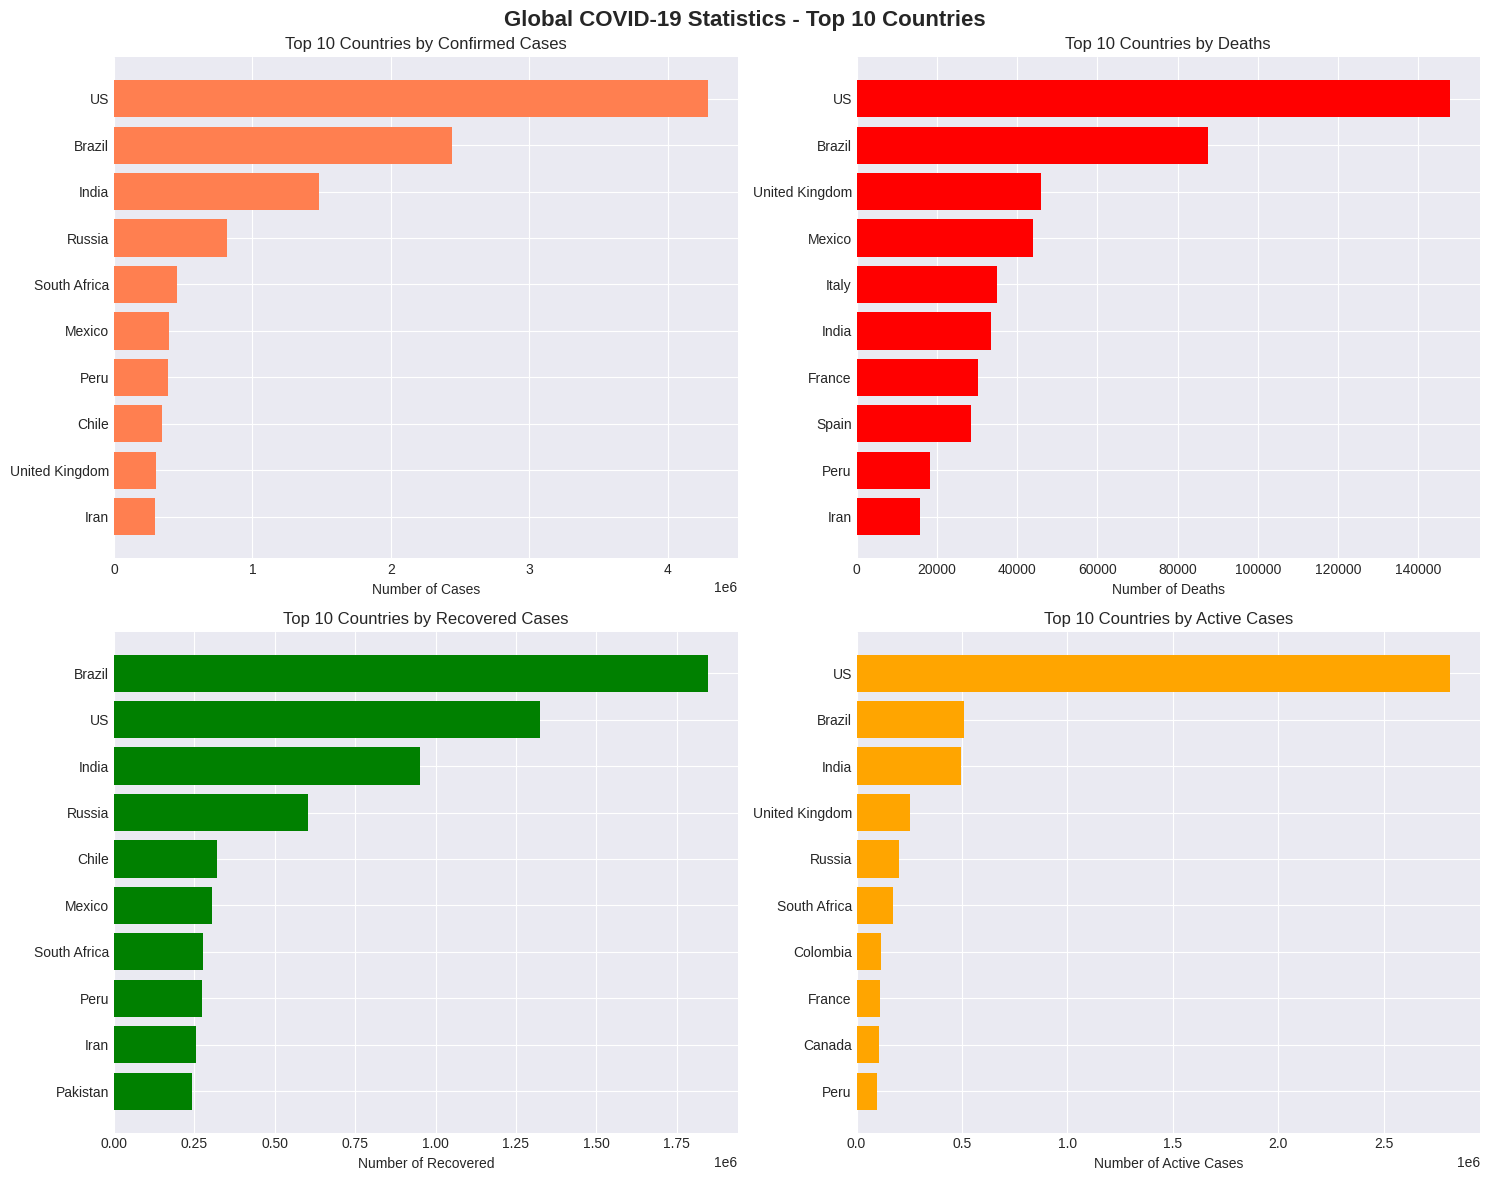

In [6]:
# Create bar charts for top 10 countries
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Global COVID-19 Statistics - Top 10 Countries', fontsize=16, fontweight='bold')

# Top 10 Confirmed Cases
top_10_confirmed = df_sorted.head(10)
axes[0, 0].barh(top_10_confirmed['Country/Region'], top_10_confirmed['Confirmed'], color='coral')
axes[0, 0].set_xlabel('Number of Cases')
axes[0, 0].set_title('Top 10 Countries by Confirmed Cases')
axes[0, 0].invert_yaxis()

# Top 10 Deaths
top_10_deaths = df_sorted.nlargest(10, 'Deaths')
axes[0, 1].barh(top_10_deaths['Country/Region'], top_10_deaths['Deaths'], color='red')
axes[0, 1].set_xlabel('Number of Deaths')
axes[0, 1].set_title('Top 10 Countries by Deaths')
axes[0, 1].invert_yaxis()

# Top 10 Recovered
top_10_recovered = df_sorted.nlargest(10, 'Recovered')
axes[1, 0].barh(top_10_recovered['Country/Region'], top_10_recovered['Recovered'], color='green')
axes[1, 0].set_xlabel('Number of Recovered')
axes[1, 0].set_title('Top 10 Countries by Recovered Cases')
axes[1, 0].invert_yaxis()

# Top 10 Active Cases
top_10_active = df_sorted.nlargest(10, 'Active')
axes[1, 1].barh(top_10_active['Country/Region'], top_10_active['Active'], color='orange')
axes[1, 1].set_xlabel('Number of Active Cases')
axes[1, 1].set_title('Top 10 Countries by Active Cases')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('/kaggle/working/output/top_10_countries.png', dpi=300, bbox_inches='tight')
plt.show()

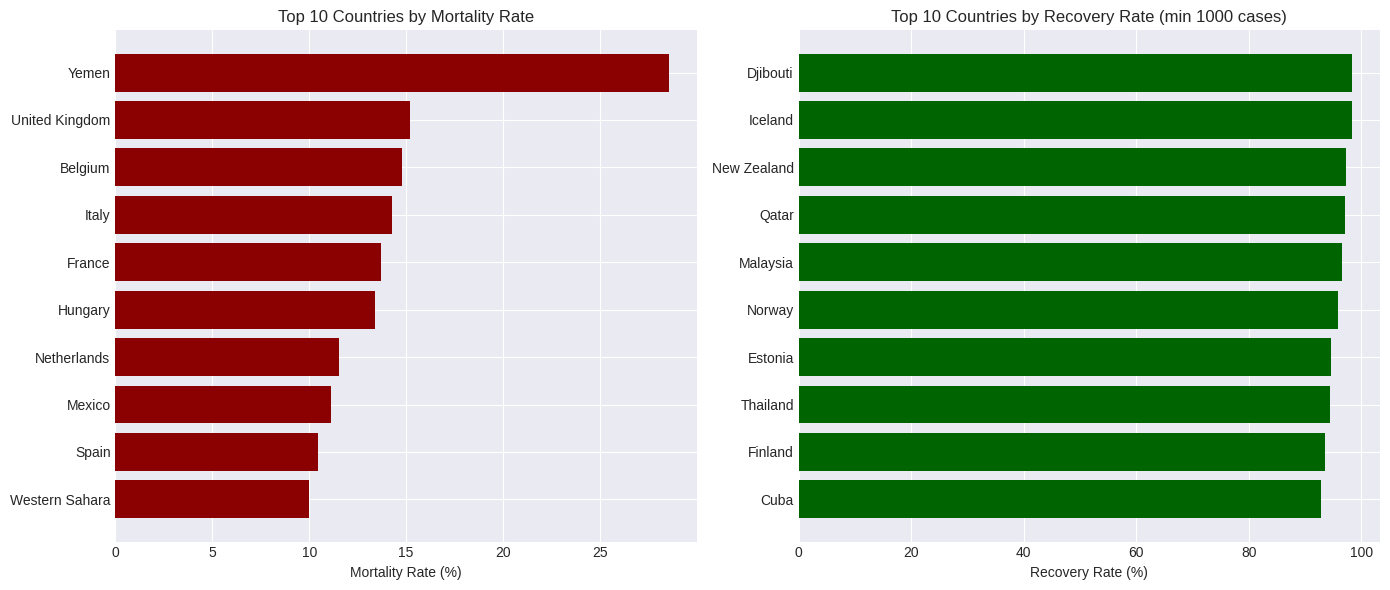

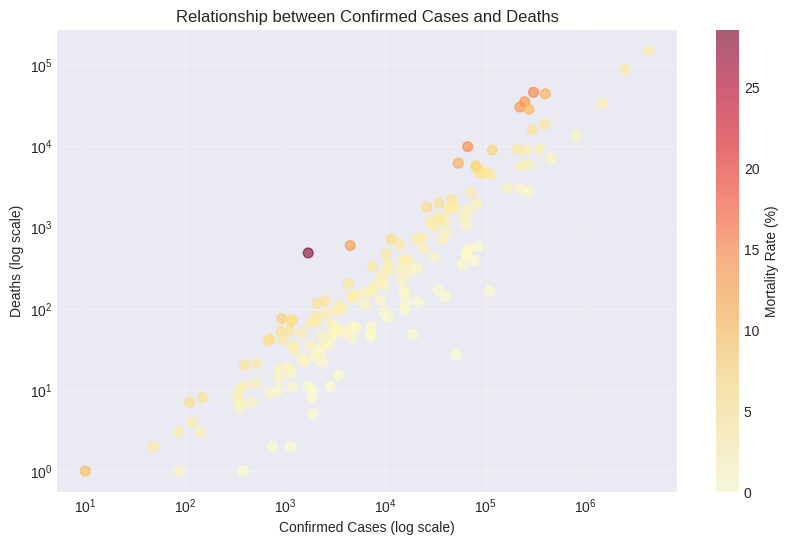

In [7]:
# Analyze mortality and recovery rates
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 Highest Mortality Rates
top_mortality = df_clean.nlargest(10, 'Mortality_Rate')
axes[0].barh(top_mortality['Country/Region'], top_mortality['Mortality_Rate'], color='darkred')
axes[0].set_xlabel('Mortality Rate (%)')
axes[0].set_title('Top 10 Countries by Mortality Rate')
axes[0].invert_yaxis()

# Top 10 Highest Recovery Rates
top_recovery = df_clean[df_clean['Confirmed'] > 1000].nlargest(10, 'Recovery_Rate')
axes[1].barh(top_recovery['Country/Region'], top_recovery['Recovery_Rate'], color='darkgreen')
axes[1].set_xlabel('Recovery Rate (%)')
axes[1].set_title('Top 10 Countries by Recovery Rate (min 1000 cases)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('/kaggle/working/output/mortality_recovery_rates.png', dpi=300, bbox_inches='tight')
plt.show()

# Scatter plot: Confirmed vs Deaths
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Confirmed'], df_clean['Deaths'], alpha=0.6, c=df_clean['Mortality_Rate'], 
            cmap='YlOrRd', s=50)
plt.xscale('log')
plt.yscale('log')
plt.colorbar(label='Mortality Rate (%)')
plt.xlabel('Confirmed Cases (log scale)')
plt.ylabel('Deaths (log scale)')
plt.title('Relationship between Confirmed Cases and Deaths')
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/output/confirmed_vs_deaths.png', dpi=300, bbox_inches='tight')
plt.show()

REGIONAL ANALYSIS BY WHO REGION
                       Total Confirmed  Total Deaths  Total Recovered  \
WHO Region                                                              
Americas                       8839286        342732          4468616   
Europe                         3299523        211144          1993723   
South-East Asia                1835297         41349          1156933   
Eastern Mediterranean          1490744         38339          1201400   
Africa                          723207         12223           440645   
Western Pacific                 292428          8249           206770   

                       Total Active  Number of Countries  Mortality Rate (%)  \
WHO Region                                                                     
Americas                    4027938                   35            3.877372   
Europe                      1094656                   56            6.399228   
South-East Asia              637015                   10       

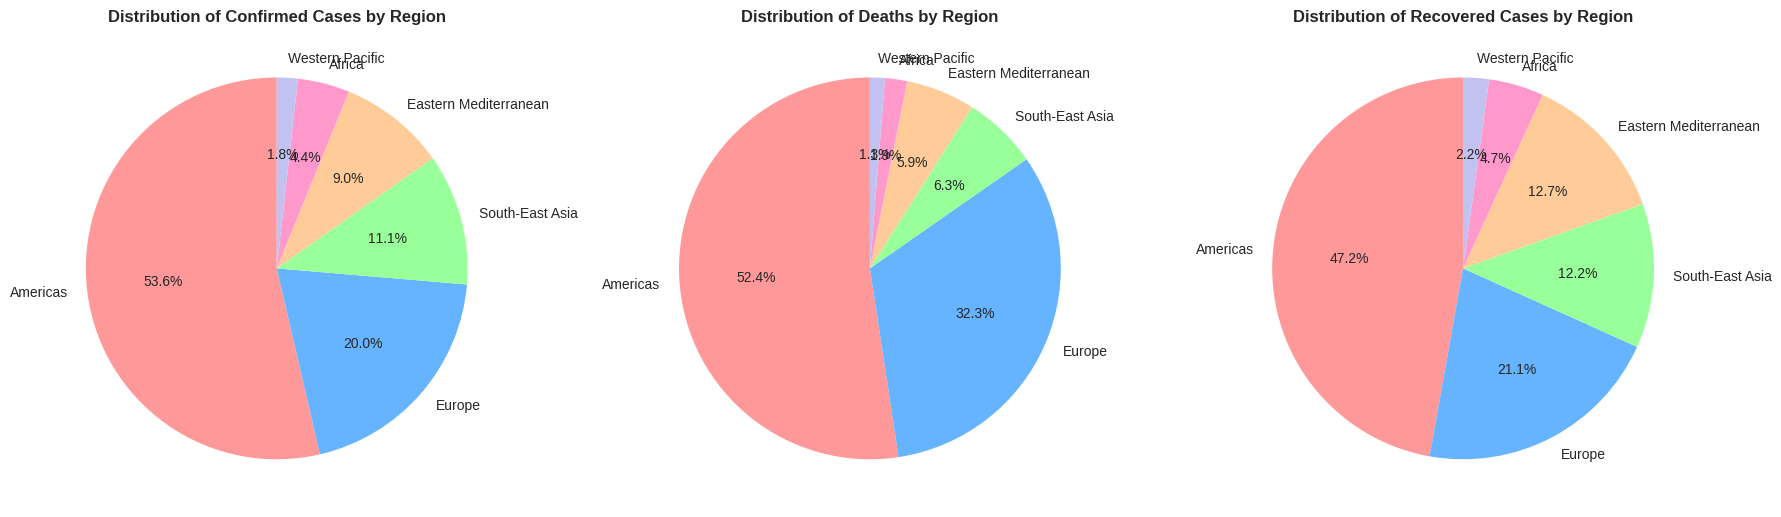

In [8]:
# Analyze by WHO Region
region_stats = df_clean.groupby('WHO Region').agg({
    'Confirmed': 'sum',
    'Deaths': 'sum',
    'Recovered': 'sum',
    'Active': 'sum',
    'Country/Region': 'count'
}).round(2)

region_stats.columns = ['Total Confirmed', 'Total Deaths', 'Total Recovered', 'Total Active', 'Number of Countries']
region_stats['Mortality Rate (%)'] = (region_stats['Total Deaths'] / region_stats['Total Confirmed']) * 100
region_stats['Recovery Rate (%)'] = (region_stats['Total Recovered'] / region_stats['Total Confirmed']) * 100
region_stats = region_stats.sort_values('Total Confirmed', ascending=False)

print("="*50)
print("REGIONAL ANALYSIS BY WHO REGION")
print("="*50)
print(region_stats)

# Create pie charts for regional distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#c2c2f0']

# Confirmed cases by region
axes[0].pie(region_stats['Total Confirmed'], labels=region_stats.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('Distribution of Confirmed Cases by Region', fontweight='bold')

# Deaths by region
axes[1].pie(region_stats['Total Deaths'], labels=region_stats.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Distribution of Deaths by Region', fontweight='bold')

# Recovered by region
axes[2].pie(region_stats['Total Recovered'], labels=region_stats.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[2].set_title('Distribution of Recovered Cases by Region', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/output/regional_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

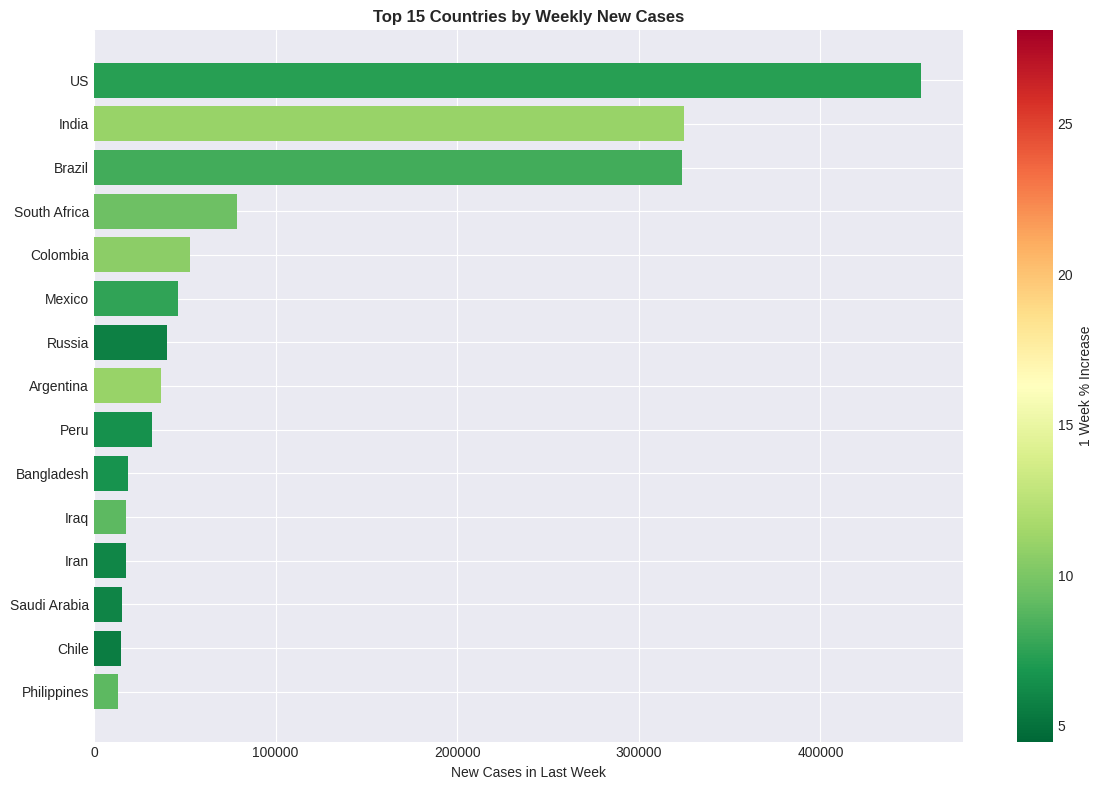

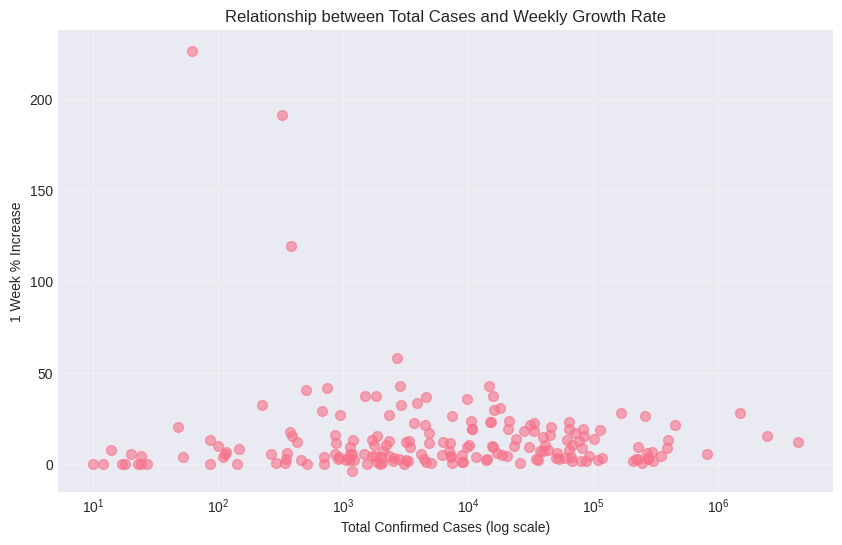

In [10]:
# Analyze week-over-week changes
# Filter countries with valid data
df_change = df_clean[df_clean['1 week change'].notna() & (df_clean['Confirmed last week'] > 0)]
df_change = df_change.nlargest(15, '1 week change')

plt.figure(figsize=(12, 8))
bars = plt.barh(df_change['Country/Region'], df_change['1 week change'], 
                color=plt.cm.RdYlGn_r(df_change['1 week % increase'] / 100))
plt.xlabel('New Cases in Last Week')
plt.title('Top 15 Countries by Weekly New Cases', fontweight='bold')
plt.gca().invert_yaxis()


sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', 
                          norm=plt.Normalize(vmin=df_change['1 week % increase'].min(), 
                                           vmax=df_change['1 week % increase'].max()))
sm.set_array([])
# Use the current axes for the colorbar
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('1 Week % Increase')

plt.tight_layout()
plt.savefig('/kaggle/working/output/weekly_changes.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation between weekly increase and current cases
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Confirmed'], df_clean['1 week % increase'], alpha=0.6, s=50)
plt.xscale('log')
plt.xlabel('Total Confirmed Cases (log scale)')
plt.ylabel('1 Week % Increase')
plt.title('Relationship between Total Cases and Weekly Growth Rate')
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/output/weekly_growth_vs_total.png', dpi=300, bbox_inches='tight')
plt.show()

OUTLIER DETECTION

Countries with unusually high confirmed cases (z-score > 3):
    Country/Region  Confirmed  Confirmed_zscore
23          Brazil    2442375          6.158229
79           India    1480073          3.641041
173             US    4290259         10.991922

Countries with unusually high deaths (z-score > 3):
     Country/Region  Deaths  Deaths_zscore
23           Brazil   87618       5.982007
173              US  148011      10.276696
177  United Kingdom   45844       3.011359

Countries with unusually high mortality rate (z-score > 3):
     Country/Region  Mortality_Rate  Mortality_zscore
16          Belgium       14.785934          3.415425
61           France       13.710790          3.103349
77          Hungary       13.399281          3.012929
85            Italy       14.256596          3.261777
177  United Kingdom       15.194824          3.534111
184           Yemen       28.562980          7.414405


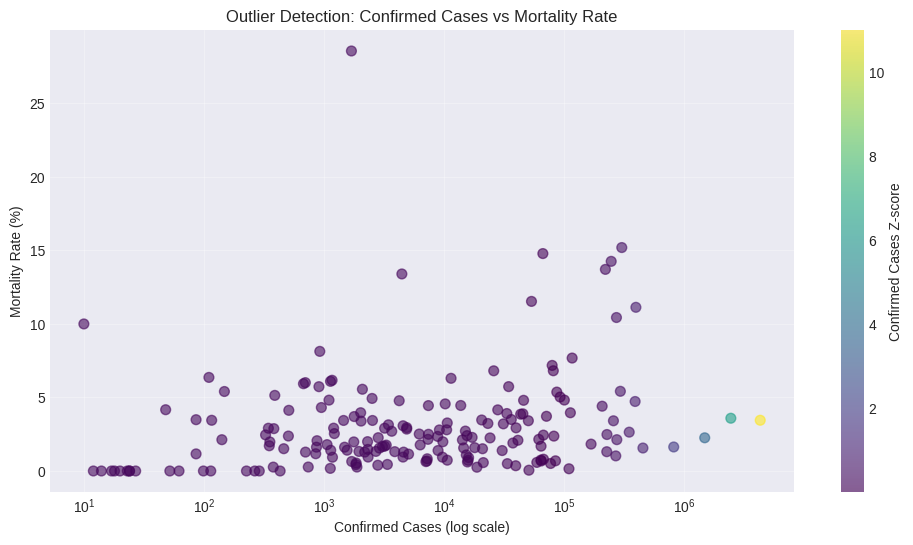

In [11]:
# Identify outliers using Z-score
from scipy import stats

# Calculate Z-scores for key metrics
df_clean['Confirmed_zscore'] = np.abs(stats.zscore(df_clean['Confirmed'].fillna(df_clean['Confirmed'].median())))
df_clean['Deaths_zscore'] = np.abs(stats.zscore(df_clean['Deaths'].fillna(df_clean['Deaths'].median())))
df_clean['Mortality_zscore'] = np.abs(stats.zscore(df_clean['Mortality_Rate'].fillna(df_clean['Mortality_Rate'].median())))

# Identify outliers (z-score > 3)
confirmed_outliers = df_clean[df_clean['Confirmed_zscore'] > 3]
deaths_outliers = df_clean[df_clean['Deaths_zscore'] > 3]
mortality_outliers = df_clean[df_clean['Mortality_zscore'] > 3]

print("="*50)
print("OUTLIER DETECTION")
print("="*50)
print(f"\nCountries with unusually high confirmed cases (z-score > 3):")
print(confirmed_outliers[['Country/Region', 'Confirmed', 'Confirmed_zscore']])

print(f"\nCountries with unusually high deaths (z-score > 3):")
print(deaths_outliers[['Country/Region', 'Deaths', 'Deaths_zscore']])

print(f"\nCountries with unusually high mortality rate (z-score > 3):")
print(mortality_outliers[['Country/Region', 'Mortality_Rate', 'Mortality_zscore']])

# Visualize outliers
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(df_clean['Confirmed'], df_clean['Mortality_Rate'], 
                     c=df_clean['Confirmed_zscore'], cmap='viridis', 
                     s=50, alpha=0.6)
plt.xscale('log')
plt.colorbar(scatter, label='Confirmed Cases Z-score')
plt.xlabel('Confirmed Cases (log scale)')
plt.ylabel('Mortality Rate (%)')
plt.title('Outlier Detection: Confirmed Cases vs Mortality Rate')
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/output/outlier_detection.png', dpi=300, bbox_inches='tight')
plt.show()

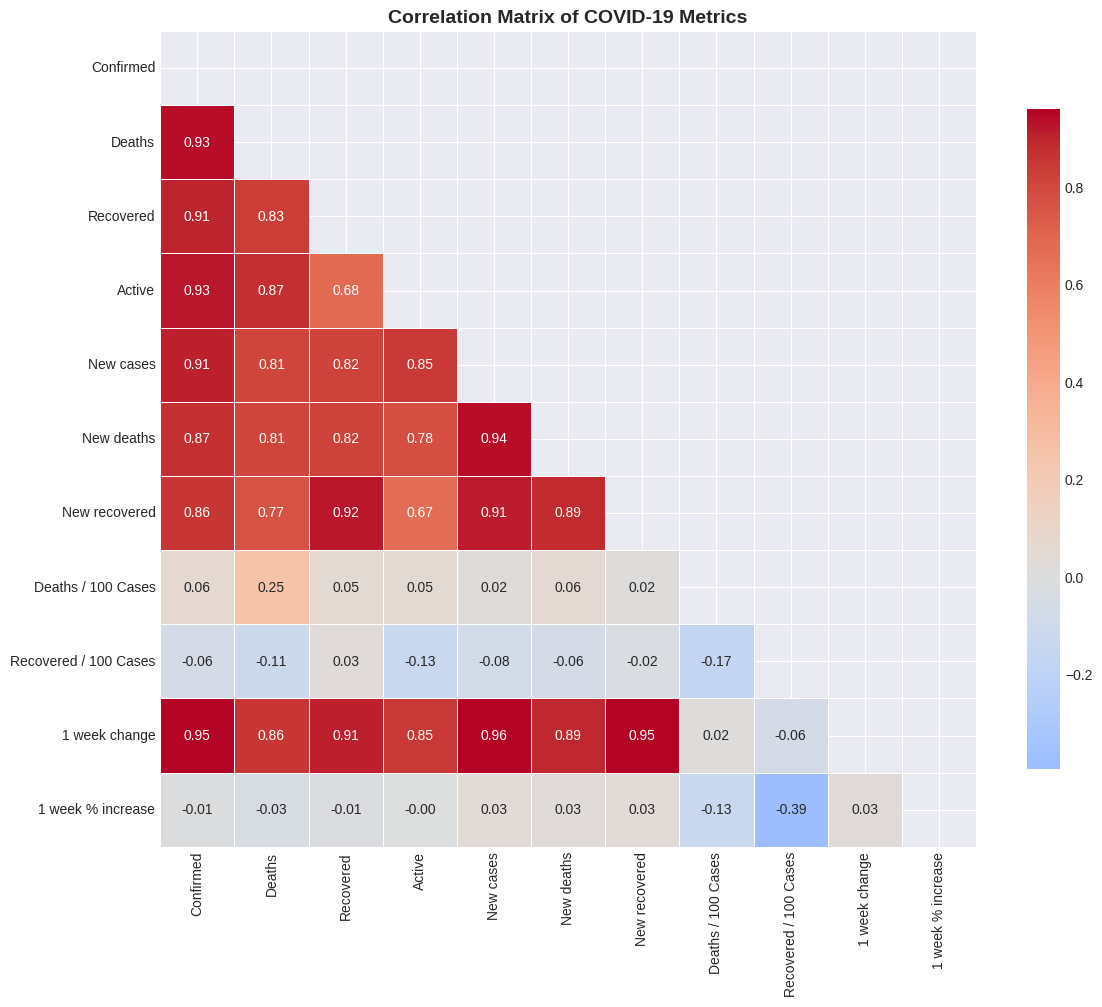

KEY CORRELATIONS

Confirmed vs Deaths correlation: 0.935
Confirmed vs Recovered correlation: 0.906
Deaths vs 1 week % increase correlation: -0.035


In [12]:
# Create correlation matrix
correlation_columns = ['Confirmed', 'Deaths', 'Recovered', 'Active', 
                       'New cases', 'New deaths', 'New recovered',
                       'Deaths / 100 Cases', 'Recovered / 100 Cases',
                       '1 week change', '1 week % increase']

# Select only numeric columns that exist
available_cols = [col for col in correlation_columns if col in df_clean.columns]
corr_matrix = df_clean[available_cols].corr()

# Create heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of COVID-19 Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/output/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print key correlations
print("="*50)
print("KEY CORRELATIONS")
print("="*50)
print(f"\nConfirmed vs Deaths correlation: {corr_matrix.loc['Confirmed', 'Deaths']:.3f}")
print(f"Confirmed vs Recovered correlation: {corr_matrix.loc['Confirmed', 'Recovered']:.3f}")
print(f"Deaths vs 1 week % increase correlation: {corr_matrix.loc['Deaths', '1 week % increase']:.3f}")

In [13]:
# Create interactive choropleth map
fig = px.choropleth(df_clean, 
                    locations="Country/Region",
                    locationmode="country names",
                    color="Mortality_Rate",
                    hover_name="Country/Region",
                    hover_data=['Confirmed', 'Deaths', 'Recovered', 'Active'],
                    color_continuous_scale="Viridis",
                    title="Global COVID-19 Mortality Rate by Country",
                    labels={'Mortality_Rate': 'Mortality Rate (%)'})

fig.update_layout(
    title_x=0.5,
    geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth')
)

fig.write_html('/kaggle/working/output/mortality_map.html')
fig.show()

# Create bubble chart
fig = px.scatter(df_clean, x="Confirmed", y="Mortality_Rate", 
                 size="Deaths", color="WHO Region",
                 hover_name="Country/Region", log_x=True,
                 title="COVID-19: Confirmed Cases vs Mortality Rate",
                 labels={"Confirmed": "Confirmed Cases (log scale)", 
                        "Mortality_Rate": "Mortality Rate (%)"})

fig.update_layout(title_x=0.5)
fig.write_html('/kaggle/working/output/bubble_chart.html')
fig.show()

In [14]:
# Generate comprehensive summary
print("="*60)
print("COVID-19 DATASET: COMPREHENSIVE SUMMARY")
print("="*60)

print(f"\n GLOBAL OVERVIEW:")
print(f"   • Total Countries/Regions: {len(df_clean)}")
print(f"   • Total Confirmed Cases: {df_clean['Confirmed'].sum():,.0f}")
print(f"   • Total Deaths: {df_clean['Deaths'].sum():,.0f}")
print(f"   • Total Recovered: {df_clean['Recovered'].sum():,.0f}")
print(f"   • Total Active Cases: {df_clean['Active'].sum():,.0f}")
print(f"   • Global Mortality Rate: {(df_clean['Deaths'].sum() / df_clean['Confirmed'].sum() * 100):.2f}%")
print(f"   • Global Recovery Rate: {(df_clean['Recovered'].sum() / df_clean['Confirmed'].sum() * 100):.2f}%")

print(f"\nTOP 5 COUNTRIES BY CONFIRMED CASES:")
for idx, row in df_sorted.head(5).iterrows():
    print(f"   {idx+1}. {row['Country/Region']}: {row['Confirmed']:,.0f} cases (Mortality: {row['Mortality_Rate']:.2f}%)")

print(f"\nHIGHEST MORTALITY RATES (>15%):")
high_mortality = df_clean[df_clean['Mortality_Rate'] > 15].sort_values('Mortality_Rate', ascending=False)
for idx, row in high_mortality.head(5).iterrows():
    print(f"   • {row['Country/Region']}: {row['Mortality_Rate']:.2f}% ({row['Deaths']:,.0f} deaths / {row['Confirmed']:,.0f} cases)")

print(f"\nHIGHEST WEEKLY GROWTH (>50%):")
high_growth = df_clean[df_clean['1 week % increase'] > 50].sort_values('1 week % increase', ascending=False)
for idx, row in high_growth.head(5).iterrows():
    print(f"   • {row['Country/Region']}: {row['1 week % increase']:.2f}% increase ({row['1 week change']:,.0f} new cases)")

print(f"\nBEST RECOVERY RATES (>90% with >1000 cases):")
best_recovery = df_clean[(df_clean['Recovery_Rate'] > 90) & (df_clean['Confirmed'] > 1000)].sort_values('Recovery_Rate', ascending=False)
for idx, row in best_recovery.head(5).iterrows():
    print(f"   • {row['Country/Region']}: {row['Recovery_Rate']:.2f}% recovery rate")

COVID-19 DATASET: COMPREHENSIVE SUMMARY

📊 GLOBAL OVERVIEW:
   • Total Countries/Regions: 187
   • Total Confirmed Cases: 16,480,485
   • Total Deaths: 654,036
   • Total Recovered: 9,468,087
   • Total Active Cases: 6,358,362
   • Global Mortality Rate: 3.97%
   • Global Recovery Rate: 57.45%

📈 TOP 5 COUNTRIES BY CONFIRMED CASES:
   1. US: 4,290,259 cases (Mortality: 3.45%)
   2. Brazil: 2,442,375 cases (Mortality: 3.59%)
   3. India: 1,480,073 cases (Mortality: 2.26%)
   4. Russia: 816,680 cases (Mortality: 1.63%)
   5. South Africa: 452,529 cases (Mortality: 1.56%)

⚠️ HIGHEST MORTALITY RATES (>15%):
   • Yemen: 28.56% (483 deaths / 1,691 cases)
   • United Kingdom: 15.19% (45,844 deaths / 301,708 cases)

📈 HIGHEST WEEKLY GROWTH (>50%):
   • Papua New Guinea: 226.32% increase (43 new cases)
   • Gambia: 191.07% increase (214 new cases)
   • Bahamas: 119.54% increase (208 new cases)
   • Zimbabwe: 57.85% increase (991 new cases)

🏆 BEST RECOVERY RATES (>90% with >1000 cases):
   • D

In [15]:
# Export all visualizations and summary to a report
with open('/kaggle/working/output/analysis_summary.txt', 'w') as f:
    f.write("COVID-19 DATASET ANALYSIS REPORT\n")
    f.write("="*60 + "\n\n")
    f.write(f"Total Countries Analyzed: {len(df_clean)}\n")
    f.write(f"Total Confirmed Cases: {df_clean['Confirmed'].sum():,.0f}\n")
    f.write(f"Total Deaths: {df_clean['Deaths'].sum():,.0f}\n")
    f.write(f"Global Mortality Rate: {(df_clean['Deaths'].sum() / df_clean['Confirmed'].sum() * 100):.2f}%\n\n")
    
    f.write("Top 10 Countries by Confirmed Cases:\n")
    for idx, row in df_sorted.head(10).iterrows():
        f.write(f"{idx+1}. {row['Country/Region']}: {row['Confirmed']:,.0f} cases\n")
    
    f.write("\nRegional Statistics:\n")
    f.write(region_stats.to_string())

# Save cleaned data
df_clean.to_csv('/kaggle/working/output/cleaned_covid_data.csv', index=False)
print("All analysis results saved to '/kaggle/working/output/' directory!")
print("\nFiles generated:")
print("   top_10_countries.png")
print("   mortality_recovery_rates.png")
print("   confirmed_vs_deaths.png")
print("   regional_distribution.png")
print("   weekly_changes.png")
print("   weekly_growth_vs_total.png")
print("   outlier_detection.png")
print("   correlation_heatmap.png")
print("   mortality_map.html")
print("   bubble_chart.html")
print("   cleaned_covid_data.csv")
print("   analysis_summary.txt")

All analysis results saved to '/kaggle/working/output/' directory!

Files generated:
  📊 top_10_countries.png
  📊 mortality_recovery_rates.png
  📊 confirmed_vs_deaths.png
  📊 regional_distribution.png
  📊 weekly_changes.png
  📊 weekly_growth_vs_total.png
  📊 outlier_detection.png
  📊 correlation_heatmap.png
  📊 mortality_map.html
  📊 bubble_chart.html
  📄 cleaned_covid_data.csv
  📄 analysis_summary.txt


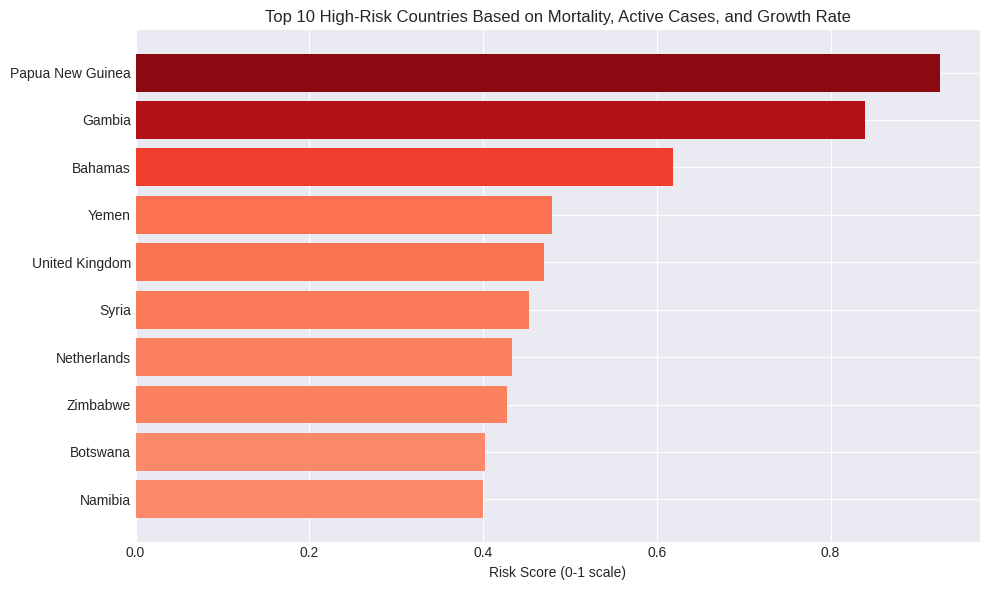


High-Risk Countries Assessment:
       Country/Region  Risk_Score  Mortality_Rate  Active_Rate  1 week % increase
130  Papua New Guinea    0.925734        0.000000    82.258065             226.32
63             Gambia    0.839478        2.453988    77.300613             191.07
11            Bahamas    0.618841        2.879581    73.298429             119.54
184             Yemen    0.479879       28.562980    22.176227               4.45
177    United Kingdom    0.470577       15.194824    84.328888               1.60
163             Syria    0.452666        5.934718    94.065282              29.12
120       Netherlands    0.433227       11.532773    88.113381               2.46
186          Zimbabwe    0.428067        1.331361    78.624260              57.85
22           Botswana    0.402113        0.270636    91.204330              41.57
118           Namibia    0.399726        0.434075    94.085730              37.13


In [17]:
# Create risk assessment score
df_clean['Risk_Score'] = (
    (df_clean['Mortality_Rate'] / df_clean['Mortality_Rate'].max()) * 0.4 +
    (df_clean['Active_Rate'] / 100) * 0.3 +
    (df_clean['1 week % increase'].fillna(0) / 100) * 0.3
)

# Top 10 highest risk countries
high_risk = df_clean.nlargest(10, 'Risk_Score')[['Country/Region', 'Risk_Score', 'Mortality_Rate', 
                                                  'Active_Rate', '1 week % increase']]

plt.figure(figsize=(10, 6))
plt.barh(high_risk['Country/Region'], high_risk['Risk_Score'], 
         color=plt.cm.Reds(high_risk['Risk_Score']))
plt.xlabel('Risk Score (0-1 scale)')
plt.title('Top 10 High-Risk Countries Based on Mortality, Active Cases, and Growth Rate')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/kaggle/working/output/risk_assessment.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nHigh-Risk Countries Assessment:")
print(high_risk.to_string())

In [18]:
import os
import zipfile
from IPython.display import FileLink, display

output_dir = '/kaggle/working/output'
zip_path = '/kaggle/working/output_files.zip'

# Create a zip file of all outputs
if os.path.exists(output_dir):
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(output_dir):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(output_dir))
                zipf.write(file_path, arcname)
    
    print(f"Zip file created: {zip_path}")
    print(f"File size: {os.path.getsize(zip_path) / (1024*1024):.2f} MB")
    
    # Create download link
    display(FileLink(zip_path))
else:
    print(f"Directory {output_dir} does not exist!")
    

Zip file created: /kaggle/working/output_files.zip
File size: 4.46 MB


/kaggle/working/output_files.zip